# Initial Organization Of Data

Starting with NANT

#### 1. Open libraries. 
.venv is being a bugger, so extra code is written below if you need to fix the environment too

In [7]:
# # 1) Activate your virtual environment
# ! source /people/gold396/.venv/bin/activate

# # 2) Install/repair pip inside that venv
# ! python -m ensurepip --upgrade

# # 3) Upgrade packaging tools
# ! python -m pip install --upgrade pip setuptools wheel

# # 4) Verify
# ! python -m pip --version
# ! which python

Looking in links: /tmp/tmpfd_5f155
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.5 MB/s  0:00:00
  Attempting uninstall: setuptools━━━━━━━━━━━━━━ 0/2 [wheel]
    Found existing installation: setuptools 53.0.00/2 [wheel]
    Uninstalling setuptools-53.0.0:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
      Successfully uninstalled setuptools-53.0.0━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [setuptools]2 [setuptools]
pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)
~/ORACLE/.venv/bin/python


In [ ]:
# ! python3 -m venv /people/gold396/ORACLE/.venv --upgrade-deps
# ! source /people/gold396/ORACLE/.venv/bin/activate
# ! python -m pip --version

pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)


In [ ]:
# ! python -m pip --version

pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)


In [15]:
! python -m pip install dask[complete] --quiet
! python -m pip install cartopy --quiet

In [ ]:
# ! source /people/gold396/ORACLE/.venv/bin/activate && python -m pip install dask[complete] --quiet && python -m pip install cartopy --quiet

In [ ]:
# ! python -m pip install xarray --quiet

In [ ]:
# ! python -m pip install windrose --quiet
from windrose import WindroseAxes

In [18]:
import dask
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
import matplotlib.axes as maxes
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from io import BytesIO
import warnings
from datetime import datetime, timedelta
import xarray as xr
import glob
warnings.filterwarnings('ignore')

#### 2. Download Data

Only one LD here. For now only using the processed stuff. Not raw. 

No surface met, closest is lidar data lowest height bin- extract it

In [19]:
ld1 = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/nant.ld.z01.b1/*")))
list(ld1.data_vars)[:8]

['rain_intensity',
 'rain_accumulated',
 'weather_code_synop_4680',
 'weather_code_synop_4677',
 'weather_code_synop_4678',
 'weather_code_nws',
 'radar_reflectivity',
 'visibility']

In [ ]:
lidar = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*")))
print(list(lidar.data_vars)[:10])
print(lidar.height.min())

['u', 'v', 'w', 'lat', 'lon', 'alt', 'time_start', 'time_end', 'ws', 'wd']
<xarray.DataArray 'height' ()> Size: 8B
array(50.)


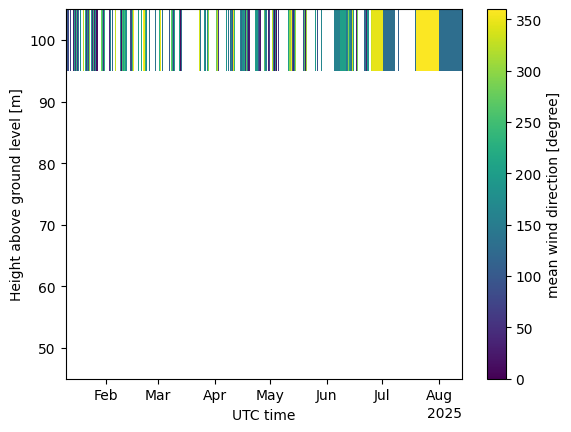

In [27]:
lidar['wd'].sel(height=slice(lidar.height.min(), 100)).transpose().plot()

While minimum height bin is 50, data doesn't start until near 100

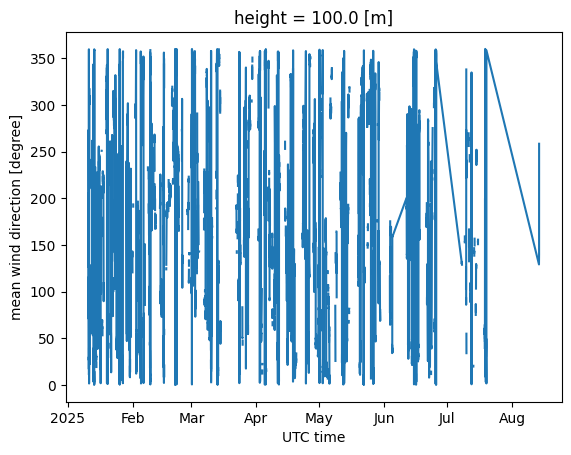

In [28]:
lidar['wd'].sel(height=100).transpose().plot()

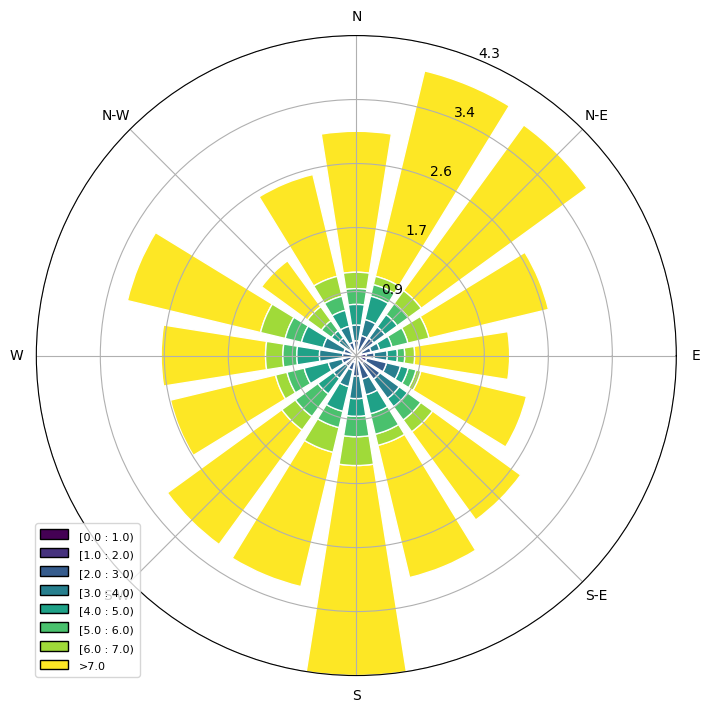

In [31]:

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)   # or WindroseAxes.from_ax()
# ax = fig.add_subplot(111, projection='windrose')  # if projection is registered
ws = lidar['ws'].sel(height=100).values  # wind speeds
wd = lidar['wd'].sel(height=100).values # wind directions
ax.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax.set_legend()

##### 2.a merged data product

In [46]:
lidar.time # every 10 minutes
ld1.time # every 10 seconds
lidar_mini = lidar[['wd', 'ti']].sel(height=100)
lidar_mini = lidar_mini.drop_vars('height')
lidar_mini.attrs["height"] = "100m"

ld1_mini = ld1[['rain_intensity', 'weather_code_nws','radar_reflectivity',
                'visibility']]   

ds = xr.merge([ld1_mini, lidar_mini], join='left')


#### 3. Initial look at disdrometer data

There appear to be 2 dominate wind directions, lets separate the different events and gather their statistics

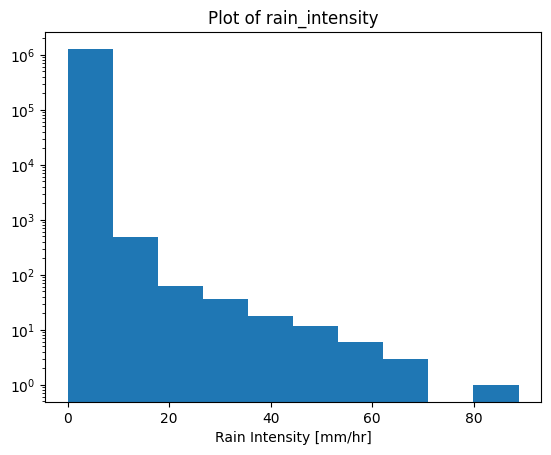

In [ ]:
plt.figure()
da = ld1['rain_intensity']
# da.where(da > 0).plot.hist()
da.plot.hist()
plt.title(f"Plot of {'rain_intensity'}")
plt.yscale('log')
plt.show()

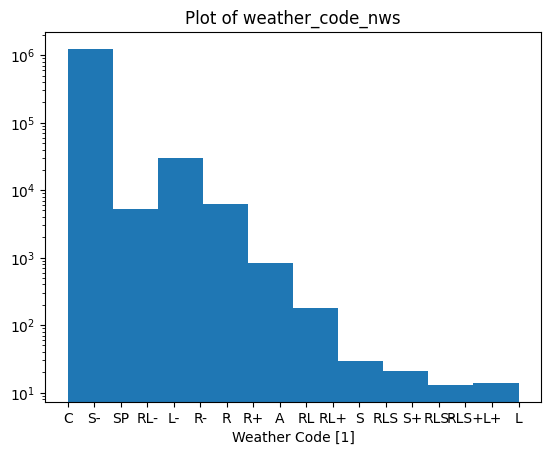

In [ ]:
plt.figure()
da = ld1['weather_code_nws']
# da.where(da > 0).plot.hist()
da.plot.hist()
plt.title(f"Plot of {'weather_code_nws'}")
plt.yscale('log')
plt.show()

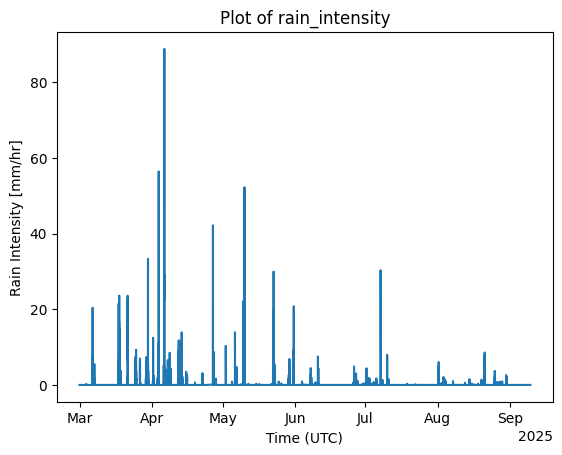

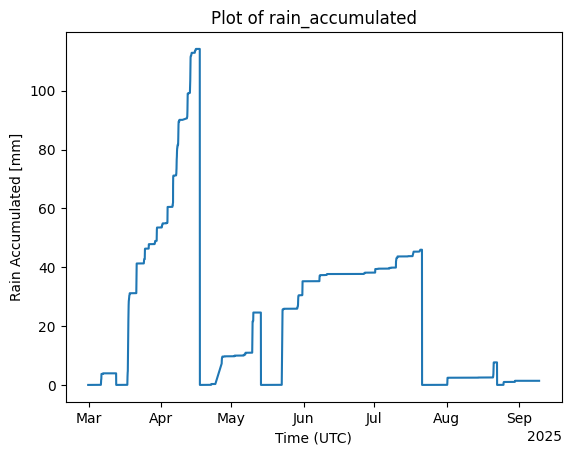

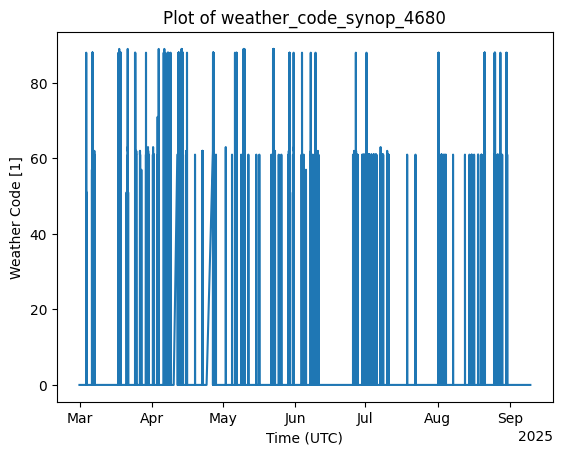

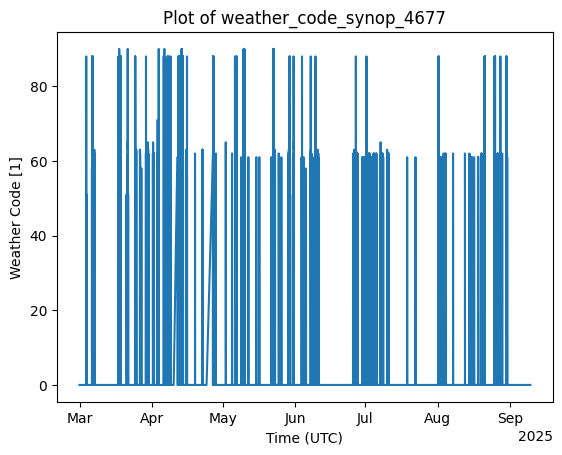

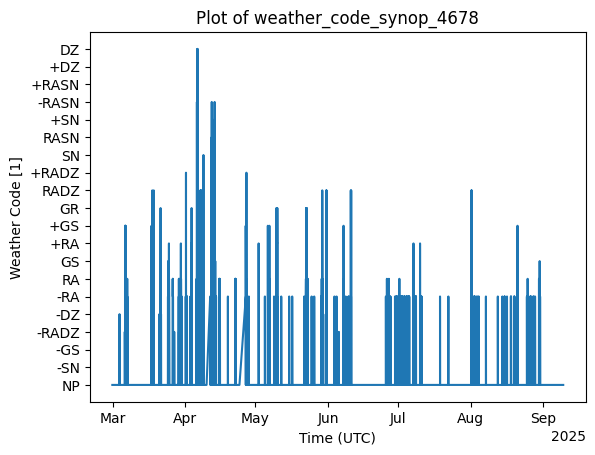

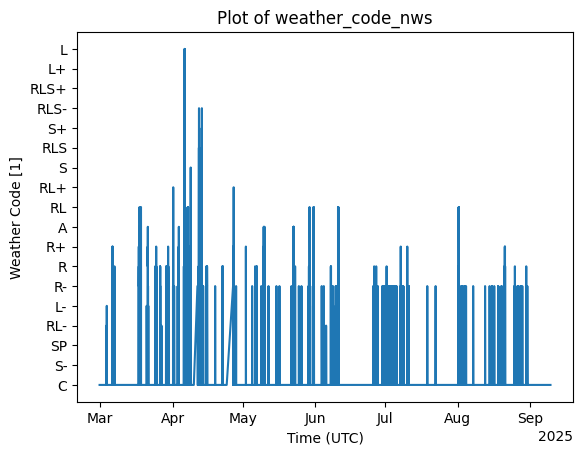

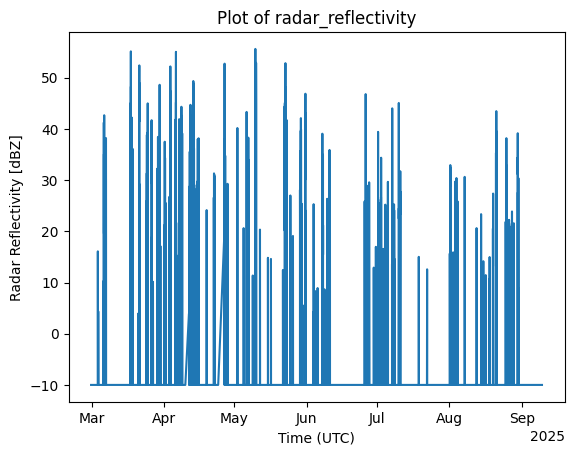

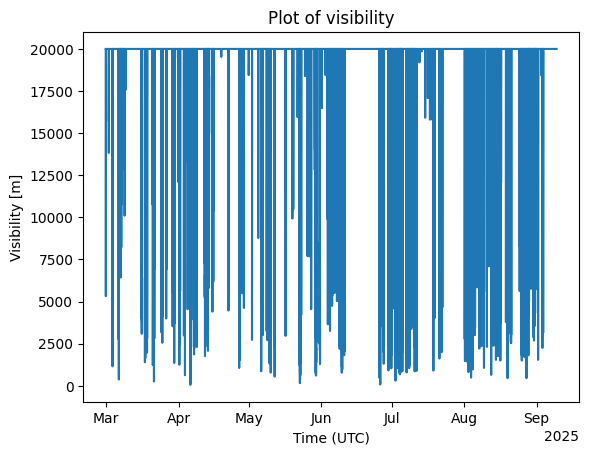

In [ ]:
for var_name in list(ld1.data_vars)[:8]:# ld1.data_vars:
    plt.figure()
    ld1[var_name].plot()
    plt.title(f"Plot of {var_name}")
    plt.show()

Now we've seen the total time series. Lets pick one event

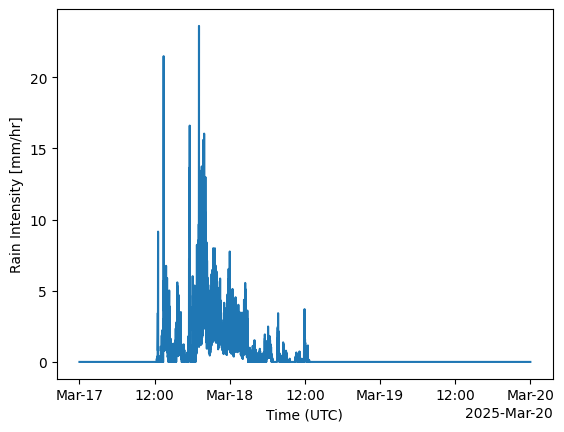

In [ ]:
ld1['rain_intensity'].sel(time=slice('2025-03-17', '2025-03-18')).plot()

In [47]:
# Find Separate Rain Events

def extract_rain_events_xr(
    ds: xr.Dataset,
    rain_var="rain_intensity",
    time_dim="time",
    rain_threshold=0.0,
    max_dry_gap="5min",        # merge wet runs separated by <= this dry gap
    min_event_duration="10min" # drop events shorter than this
):
    ds = ds.sortby(time_dim)

    t = ds[time_dim].to_index()
    if not isinstance(t, pd.DatetimeIndex):
        raise ValueError(f"{time_dim} must be datetime-like")

    wet = (ds[rain_var].fillna(0) > rain_threshold).astype(bool).values
    n = wet.size
    if n == 0:
        return xr.Dataset(), ds.assign(event_id=xr.full_like(ds[time_dim], np.nan, dtype=float))

    # Identify wet runs (start/end indices) on the raw wet mask
    wet_int = wet.astype(np.int8)
    d = np.diff(wet_int, prepend=0, append=0)
    starts = np.where(d == 1)[0]
    ends_excl = np.where(d == -1)[0]  # exclusive
    ends = ends_excl - 1              # inclusive

    if len(starts) == 0:
        event_id = xr.DataArray(np.full(n, np.nan), coords={time_dim: ds[time_dim]}, dims=(time_dim,))
        return xr.Dataset(), ds.assign(event_id=event_id)

    # Merge runs separated by short dry gaps
    max_gap = pd.to_timedelta(max_dry_gap)
    merged = []
    cur_s, cur_e = starts[0], ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        gap = t[s] - t[cur_e]  # time between last wet point and next wet start
        if gap <= max_gap:
            cur_e = e
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e
    merged.append((cur_s, cur_e))

    # Build events and apply min duration
    min_dur = pd.to_timedelta(min_event_duration)
    event_rows = []
    for i, (s, e) in enumerate(merged, start=1):
        start_time = t[s]
        end_time = t[e]
        duration = end_time - start_time
        if duration >= min_dur:
            event_rows.append((i, start_time, end_time, duration))

    events = pd.DataFrame(event_rows, columns=["event_id", "start", "end", "duration"])

    # Label time points with event_id
    labels = np.full(n, np.nan)
    for _, r in events.iterrows():
        # indices for this event
        s = t.get_loc(r["start"])
        e = t.get_loc(r["end"])
        labels[s:e+1] = r["event_id"]

    event_id = xr.DataArray(labels, coords={time_dim: ds[time_dim]}, dims=(time_dim,))
    ds_labeled = ds.assign(event_id=event_id)

    # Return events also as xarray Dataset (optional)
    events_ds = xr.Dataset(
        data_vars=dict(
            start=("event", events["start"].values.astype("datetime64[ns]")),
            end=("event", events["end"].values.astype("datetime64[ns]")),
            duration=("event", events["duration"].values.astype("timedelta64[ns]")),
            event_id=("event", events["event_id"].values.astype(int)),
        ),
        coords=dict(event=np.arange(len(events)))
    )

    return events_ds, ds_labeled

# events_ds, ds_labeled = extract_rain_events_xr(
#     ds,
#     rain_var="rain_intensity",
#     max_dry_gap="5min",
#     min_event_duration="10min"
# )

# events_ds
# ds_labeled has ds_labeled["event_id"] aligned with time; NaN means not in a kept event

In [57]:
def circular_mean_deg_xr(da_deg, dim="time"):
    rad = np.deg2rad(da_deg)
    mean_sin = xr.apply_ufunc(np.sin, rad).mean(dim)
    mean_cos = xr.apply_ufunc(np.cos, rad).mean(dim)
    ang = xr.apply_ufunc(np.arctan2, mean_sin, mean_cos)
    return (xr.apply_ufunc(np.rad2deg, ang) + 360) % 360

def per_event_stats(ds_labeled, time_dim="time",
                    rain_var="rain_intensity",
                    wind_var="wd",
                    viz_var="visibility",
                    dbz_var="radar_reflectivity",
                    codes_var="weather_code_nws",
                    turb_var="ti",
                    dt_seconds=10):
    """
    ds_labeled must contain:
      - ds_labeled[rain_var] in mm/hour
      - ds_labeled[wind_var] in degrees
      - ds_labeled["event_id"] labeling timesteps (NaN when not in an event)

    Computes per-event:
      start, duration, rain_sum_mm, rain_max, rain_median, wind_dir_mean
    """
    # keep only event times, group by event_id
    g = ds_labeled.where(ds_labeled["event_id"].notnull(), drop=True).groupby("event_id")

    # Convert mm/hour samples to mm per sample:
    # mm/hr * (dt_seconds / 3600) = mm
    rain_mm_per_step = ds_labeled[rain_var] * (dt_seconds / 3600.0)

    def one_event(d):
        start = d[time_dim].min(time_dim)
        end   = d[time_dim].max(time_dim)
        duration = end - start

        rain_sum_mm = (rain_mm_per_step.sel({time_dim: d[time_dim]})).sum(time_dim).compute()
        rain_max = d[rain_var].max(time_dim).compute()
        rain_mean = d[rain_var].mean(time_dim).compute()
        visibility_mean = d[viz_var].mean(time_dim).compute()
        dbz_mean = d[dbz_var].mean(time_dim).compute()
        codes_unique = np.unique(d[codes_var].compute().values)
        wind_dir_mean = circular_mean_deg_xr(d[wind_var].compute(), dim=time_dim)
        ti_mean = d[turb_var].mean(time_dim).compute()

        return xr.Dataset(
            {
                "start": start,
                "duration": duration,
                "rain_sum_mm": rain_sum_mm,
                "rain_max_intensity": rain_max,
                "rain_mean_intensity": rain_mean,
                "wind_dir_mean": wind_dir_mean,
                "visibility_mean": visibility_mean,
                "dbz_mean": dbz_mean,
                "codes_unique": codes_unique,
                "ti_mean": ti_mean
            }
        )

    return g.map(one_event)

# usage:
# per_event = per_event_stats(ds_labeled, dt_seconds=10)
# per_event

In [49]:
events_ds, ds_labeled = extract_rain_events_xr(
    ds,
    rain_var="rain_intensity",
    max_dry_gap="5min",
    min_event_duration="10min"
)

In [ ]:
per_event = per_event_stats(ds_labeled, dt_seconds=10)
per_event

In [ ]:
def plot_rain_event(ds_labeled, per_event, event_id,
                    time_dim="time",
                    vars_to_plot=("rain_intensity", "dbz", "visibility", "ti", "wind_direction"),
                    rain_var="rain_intensity"):
    """
    Plot time series for one labeled event.

    Parameters
    ----------
    ds_labeled : xr.Dataset
        Must contain event_id(time_dim) plus the variables you want to plot.
    per_event : xr.Dataset
        Per-event stats with dim 'event_id' (as produced by your groupby-map).
        Must include the fields listed in your message.
    event_id : int
        Which event to plot.
    vars_to_plot : tuple[str]
        Variables to plot as separate subplots (if present in ds_labeled).
    """

    if "event_id" not in ds_labeled:
        raise ValueError("ds_labeled must include variable 'event_id'")

    # Select event slice
    m = ds_labeled["event_id"] == event_id
    if m.sum().item() == 0:
        raise ValueError(f"No samples found for event_id={event_id}")

    dse = ds_labeled.where(m, drop=True)

    # Pull per-event metadata (handle xarray scalars)
    pe = per_event.sel(event_id=event_id)

    def _scalar(x):
        try:
            return x.item()
        except Exception:
            return x.values

    start = _scalar(pe["start"]) if "start" in pe else dse[time_dim].min().item()
    duration = _scalar(pe["duration"]) if "duration" in pe else (dse[time_dim].max() - dse[time_dim].min()).item()

    codes = None
    if "codes_unique" in pe:
        codes = _scalar(pe["codes_unique"])

    # Title text
    title_parts = [f"Event {event_id}", f"start={pd.to_datetime(start)}", f"duration={pd.to_timedelta(duration)}"]
    if codes is not None:
        title_parts.append(f"codes={codes}")
    title = " | ".join(title_parts)

    # Figure
    existing = [v for v in vars_to_plot if v in dse.data_vars]
    n = len(existing)
    if n == 0:
        raise ValueError("None of vars_to_plot exist in ds_labeled")

    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6*n), sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, v in zip(axes, existing):
        ax.plot(dse[time_dim].values, dse[v].values, lw=1.2)
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.25)

        # Optional: highlight raining vs not (within event window it should mostly be rain,
        # but if you merged across small dry gaps you may see zeros)
        if v == rain_var:
            ax.axhline(0, color="k", lw=0.8, alpha=0.4)

    # Add a small per-event stats block on the first axis
    stats_lines = []
    for k in ["rain_sum_mm", "rain_max_intensity", "rain_mean_intensity",
              "wind_dir_mean", "visibility_mean", "dbz_mean", "ti_mean"]:
        if k in pe:
            val = _scalar(pe[k])
            stats_lines.append(f"{k}={val:.3g}" if np.isscalar(val) and np.isfinite(val) else f"{k}={val}")
    if stats_lines:
        axes[0].text(0.01, 0.98, "\n".join(stats_lines),
                     transform=axes[0].transAxes, va="top", ha="left",
                     fontsize=9, family="monospace",
                     bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85))

    axes[0].set_title(title)
    axes[-1].set_xlabel(time_dim)

    return fig, axes

In [ ]:
fig, axes = plot_rain_event(
    ds_labeled, per_event, event_id=12,
    vars_to_plot=("rain_intensity", "dbz", "visibility", "ti", "wind_direction")
)
plt.show()